### Building Transformer Decoder Block from Scratch

Decoder Block Output:
 [[  1.93453685  10.56941297  -3.49762604   0.83264323 -17.33176576
   18.33035958  -7.96137674   7.82806197]
 [ 10.40285295  12.75892152  -3.09724802   2.2546146  -18.82995418
   16.51347019  -4.84029729   4.93872787]
 [ 28.64337132  11.84399949   6.47455064   2.91894644 -21.62871959
    8.48833418  -1.4818029    9.37957321]
 [ 32.70036832  11.19540555   6.76183219   4.84850336 -20.6159282
    7.32059391  -1.53641433   9.02448991]
 [ 34.90720409   4.05826198   5.09354217   9.05055557 -17.58419565
    6.50105526  -0.32554803   5.72559638]
 [  0.32458761  -0.27289639   2.82892892  -8.62187099 -14.11453448
   26.54300289  -9.96683241   9.60551969]]


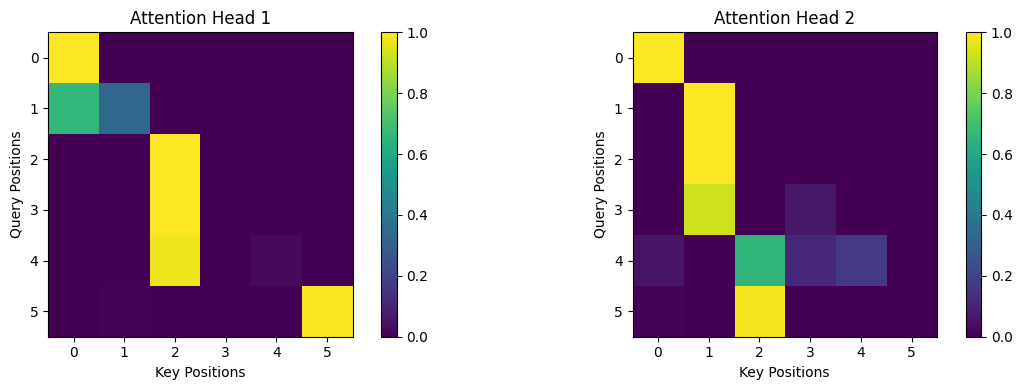

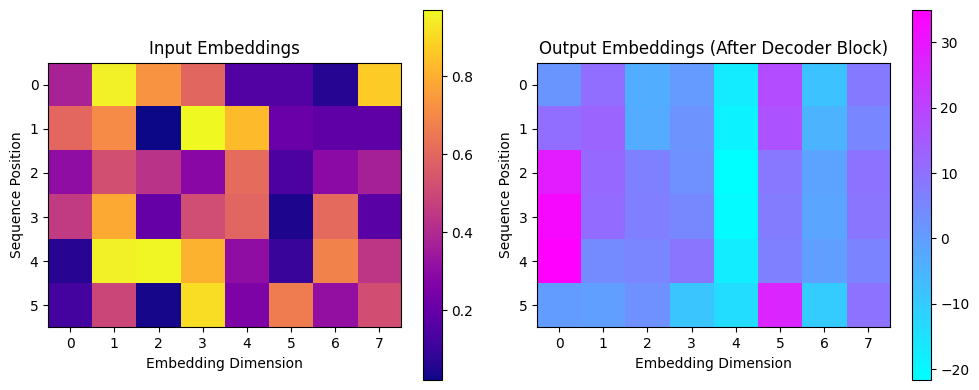

In [5]:
import numpy as np
import matplotlib.pyplot as plt

 
# Utility Functions
 
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

def layer_norm(X, eps=1e-5):
    mean = X.mean(axis=-1, keepdims=True)
    var = X.var(axis=-1, keepdims=True)
    return (X - mean) / np.sqrt(var + eps)

def causal_mask(seq_len):
    return np.tril(np.ones((seq_len, seq_len)))

def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = np.dot(Q, K.T) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)
    attention_weights = softmax(scores)
    output = np.dot(attention_weights, V)
    return output, attention_weights


 
# Multi-Head Causal Self-Attention
 
class MultiHeadCausalSelfAttention:
    def __init__(self, d_model, num_heads):
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        
        self.W_Q = np.random.randn(d_model, d_model)
        self.W_K = np.random.randn(d_model, d_model)
        self.W_V = np.random.randn(d_model, d_model)
        self.W_O = np.random.randn(d_model, d_model)
    
    def split_heads(self, X):
        seq_len = X.shape[0]
        return X.reshape(seq_len, self.num_heads, self.d_head).transpose(1, 0, 2)
    
    def combine_heads(self, X):
        seq_len = X.shape[1]
        return X.transpose(1, 0, 2).reshape(seq_len, self.d_model)
    
    def forward(self, X):
        seq_len = X.shape[0]
        mask = causal_mask(seq_len)
        
        Q = X @ self.W_Q
        K = X @ self.W_K
        V = X @ self.W_V
        
        Q_heads = self.split_heads(Q)
        K_heads = self.split_heads(K)
        V_heads = self.split_heads(V)
        
        head_outputs = []
        attention_maps = []
        
        for i in range(self.num_heads):
            out, attn = scaled_dot_product_attention(
                Q_heads[i], K_heads[i], V_heads[i], mask=mask
            )
            head_outputs.append(out)
            attention_maps.append(attn)
        
        combined = self.combine_heads(np.array(head_outputs))
        output = combined @ self.W_O
        
        return output, attention_maps


 
# Feed-Forward Network (FFN)
 
class FeedForward:
    def __init__(self, d_model, d_ff):
        self.W1 = np.random.randn(d_model, d_ff)
        self.b1 = np.zeros(d_ff)
        self.W2 = np.random.randn(d_ff, d_model)
        self.b2 = np.zeros(d_model)
    
    def forward(self, X):
        return np.maximum(0, X @ self.W1 + self.b1) @ self.W2 + self.b2  # ReLU


 
# Transformer Decoder Block
 

class TransformerDecoderBlock:
    def __init__(self, d_model, num_heads, d_ff):
        self.attention = MultiHeadCausalSelfAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
    
    def forward(self, X):
        # Pre-LayerNorm + Attention
        X_norm1 = layer_norm(X)
        attn_out, attention_maps = self.attention.forward(X_norm1)
        X = X + attn_out  # Residual
        
        # Pre-LayerNorm + FeedForward
        X_norm2 = layer_norm(X)
        ffn_out = self.ffn.forward(X_norm2)
        X = X + ffn_out  # Residual
        
        return X, attention_maps


 
# Example Input
 

np.random.seed(42)

seq_len = 6
d_model = 8
num_heads = 2
d_ff = 32

X = np.random.rand(seq_len, d_model)

decoder_block = TransformerDecoderBlock(d_model, num_heads, d_ff)
output, attention_maps = decoder_block.forward(X)

print("Decoder Block Output:\n", output)


 
# Visualization: Attention per Head
 

fig, axes = plt.subplots(1, num_heads, figsize=(12, 4))

for i in range(num_heads):
    im = axes[i].imshow(attention_maps[i], cmap="viridis")
    axes[i].set_title(f"Attention Head {i+1}")
    axes[i].set_xlabel("Key Positions")
    axes[i].set_ylabel("Query Positions")
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()


 
# Visualization: Input vs Output
 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(X, cmap="plasma")
axes[0].set_title("Input Embeddings")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(output, cmap="cool")
axes[1].set_title("Output Embeddings (After Decoder Block)")
plt.colorbar(im1, ax=axes[1])

for ax in axes:
    ax.set_xlabel("Embedding Dimension")
    ax.set_ylabel("Sequence Position")

plt.tight_layout()
plt.show()